# Asociačné pravidlá pre úmrtie (Apriori) - 4. vlna 

Tento notebook:
- vytvorí cieľový atribút Zomrel zo stĺpca Závažnosť priebehu ochorenia
- odstráni identifikačné a nerelevantné stĺpce
- doplní chýbajúce hodnoty pomocou robustnej MICE imputácie
- vytvorí vekové kategórie (vrátane seniorov 80+)
- automaticky vyberie štatisticky významné atribúty
- pre laboratórne markery použije výhradne posledné známe merania (s vyčisteným názvom, napr. S-Urea_Vysoke)
- vygeneruje asociačné pravidlá algoritmom Apriori v tvare faktor(y) → Zomrel

In [1]:
# Import potrebných knižníc

import os
import re
import math
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.stats import chi2_contingency, spearmanr
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from mlxtend.frequent_patterns import apriori, association_rules
from matplotlib_venn import venn2


In [2]:
# Načítanie datasetu

DATA_PATH = "4. vlna všetko 28-11-2024.xlsx"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Súbor '{DATA_PATH}' sa nenašiel. Uprav DATA_PATH na správnu cestu k datasetu."
    )

if DATA_PATH.lower().endswith(".csv"):
    vlna_4 = pd.read_csv(DATA_PATH)
else:
    vlna_4 = pd.read_excel(DATA_PATH)

print("Shape pôvodného datasetu:", vlna_4.shape)
vlna_4.head()


Shape pôvodného datasetu: (1251, 274)


,Poradie,Meno,Pohlavie,Vek,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,HLN Dg.,Diagnózy,...,ANOPYRIN,Prekonal COVID-19,S-PBNP first,S-PBNP last,S-PBNP min,S-PBNP max,S-VITD first,S-VITD last,S-VITD min,S-VITD max
0,1,TOHAMJTTYUMQPEAPLOLF,Žena,67,01.01.2022,1,10.01.2022,7,J12.8 | Iný vírusový zápal pľúc | B,U07.3 | Potvrdená infekcia COVID-19 PCR testom...,...,False,False,994.3,994.3,994.3,994.3,38.77,38.77,38.77,38.77
1,2,AIHAMJYHUHJYXCAJUNKI,Muž,48,10.01.2022,1,17.01.2022,1,J12.8 | Iný vírusový zápal pľúc | B,U07.3 | Potvrdená infekcia COVID-19 PCR testom...,...,False,False,120.4,120.4,120.4,120.4,26.42,26.42,26.42,26.42
2,3,MPHAMXBJBYECRYQFOGLB,Muž,67,03.04.2022,1,13.04.2022,1,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | B; _x000D_\n...,...,False,True,271.5,271.5,271.5,271.5,19.37,19.37,19.37,19.37
3,4,XCHAMXHMMHMHFDVLLWER,Muž,84,08.10.2023,1,12.10.2023,7,J12.8 | Iný vírusový zápal pľúc | B,U07.3 | Potvrdená infekcia COVID-19 PCR testom...,...,False,False,15018.0,6790.0,6790.0,15018.0,NaN,NaN,NaN,NaN
4,5,OKHAMXHXAAHXCYABXARB,Muž,74,28.07.2022,1,08.08.2022,1,J12.8 | Iný vírusový zápal pľúc | Z,U07.1 | Potvrdená infekcia COVID-19 | Z; _x000...,...,False,True,1272.0,1272.0,1272.0,1272.0,18.32,18.32,18.32,18.32


In [3]:
# Definovanie pomocných funkcií pre názvy stĺpcov 

def normalize_name(name: str) -> str:
    if name is None:
        return ""
    s = str(name).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"\s+", " ", s)
    return s

def first_existing_column(df, candidates):
    norm_map = {normalize_name(c): c for c in df.columns}
    for cand in candidates:
        col = norm_map.get(normalize_name(cand))
        if col is not None:
            return col
    return None

def safe_bool_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    if pd.api.types.is_numeric_dtype(series):
        unique = set(pd.Series(series.dropna()).unique().tolist())
        if unique.issubset({0, 1}):
            return series.fillna(0).astype(int).astype(bool)
    return None


In [4]:
# Kontrola množstva chýbajúcich hodnôt pred úpravami

total_cells_start = vlna_4.size
missing_cells_start = vlna_4.isnull().sum().sum()
percent_missing_start = (missing_cells_start / total_cells_start) * 100

print(f"--- STAV NA ZAČIATKU ---")
print(f"Celkový počet buniek: {total_cells_start}")
print(f"Počet chýbajúcich hodnôt: {missing_cells_start}")
print(f"Percento chýbajúcich hodnôt: {percent_missing_start:.2f} %")

--- STAV NA ZAČIATKU ---
Celkový počet buniek: 342774
Počet chýbajúcich hodnôt: 49848
Percento chýbajúcich hodnôt: 14.54 %


In [5]:
# Vytvorenie atribútu Zomrel zo stĺpca Závažnosť priebehu ochorenia

severity_col = first_existing_column(vlna_4, [
    "Závažnosť priebehu ochorenia",
    "Zavaznost priebehu ochorenia"
])

if severity_col is None:
    raise KeyError("V datasete sa nenašiel stĺpec 'Závažnosť priebehu ochorenia'.")

vlna_4["Zomrel"] = vlna_4[severity_col].apply(lambda x: 1 if pd.notna(x) and x == 3 else 0).astype(int)
print(f"Úmrtia v datasete: {vlna_4['Zomrel'].sum()} z {len(vlna_4)}")

# Odstránenie nerelevantných stĺpcov (balastov)
drop_candidates = [
    "ID", "id", "Kód príjmu", "Kod prijmu", "Kód prijmu",
    "Kód prepustenia", "Kod prepustenia",'HLN Dg', 'Diagnózy', 'DRG výkony', 'Mikrobiológia', 'Epikríza', 
    'Terajšie ochorenie', 'Dôvod hospitalizácie', 'Objektívny nález', 
    'Osobná anamnéza', 'Lieková anamnéza', 'Návyková anamnéza', 
    'Epidemiologická anamnéza', 'SVLZ správy', 'Liečba', "HLN Dg.", "Prekonal COVID-19", severity_col
]
cols_to_drop = [c for c in [first_existing_column(vlna_4, [cand]) for cand in drop_candidates] if c is not None]
vlna_4 = vlna_4.drop(columns=list(dict.fromkeys(cols_to_drop)), errors="ignore")

print("Shape po vytvorení cieľa a odstránení nerelevantných stĺpcov:", vlna_4.shape)
vlna_4.head()


Úmrtia v datasete: 128 z 1251
Shape po vytvorení cieľa a odstránení nerelevantných stĺpcov: (1251, 257)


,Poradie,Meno,Pohlavie,Vek,Dátum príjmu,Dátum prepustenia,A04.7,Unnamed: 23,Fajčenie,Alkohol,...,ANOPYRIN,S-PBNP first,S-PBNP last,S-PBNP min,S-PBNP max,S-VITD first,S-VITD last,S-VITD min,S-VITD max,Zomrel
0,1,TOHAMJTTYUMQPEAPLOLF,Žena,67,01.01.2022,10.01.2022,False,NaN,False,False,...,False,994.3,994.3,994.3,994.3,38.77,38.77,38.77,38.77,1
1,2,AIHAMJYHUHJYXCAJUNKI,Muž,48,10.01.2022,17.01.2022,False,NaN,False,False,...,False,120.4,120.4,120.4,120.4,26.42,26.42,26.42,26.42,0
2,3,MPHAMXBJBYECRYQFOGLB,Muž,67,03.04.2022,13.04.2022,False,NaN,False,False,...,False,271.5,271.5,271.5,271.5,19.37,19.37,19.37,19.37,0
3,4,XCHAMXHMMHMHFDVLLWER,Muž,84,08.10.2023,12.10.2023,False,NaN,False,False,...,False,15018.0,6790.0,6790.0,15018.0,NaN,NaN,NaN,NaN,1
4,5,OKHAMXHXAAHXCYABXARB,Muž,74,28.07.2022,08.08.2022,False,NaN,False,False,...,False,1272.0,1272.0,1272.0,1272.0,18.32,18.32,18.32,18.32,0


In [6]:
# Spracovanie dátumov a výpočet dĺžky hospitalizácie

admit_col = first_existing_column(vlna_4, ["Dátum príjmu", "Datum prijmu"])
discharge_col = first_existing_column(vlna_4, ["Dátum prepustenia", "Datum prepustenia"])

if admit_col is not None:
    vlna_4[admit_col] = pd.to_datetime(vlna_4[admit_col], errors="coerce")
if discharge_col is not None:
    vlna_4[discharge_col] = pd.to_datetime(vlna_4[discharge_col], errors="coerce")

if admit_col is not None and discharge_col is not None:
    vlna_4["Dlzka_hospitalizacie"] = (vlna_4[discharge_col] - vlna_4[admit_col]).dt.days
    vlna_4.loc[vlna_4["Dlzka_hospitalizacie"] < 1, "Dlzka_hospitalizacie"] = 1
    vlna_4 = vlna_4.drop(columns=[admit_col, discharge_col], errors="ignore")

vlna_4.head()


,Poradie,Meno,Pohlavie,Vek,A04.7,Unnamed: 23,Fajčenie,Alkohol,S-Bil-T first,S-Bil-T last,...,S-PBNP first,S-PBNP last,S-PBNP min,S-PBNP max,S-VITD first,S-VITD last,S-VITD min,S-VITD max,Zomrel,Dlzka_hospitalizacie
0,1,TOHAMJTTYUMQPEAPLOLF,Žena,67,False,NaN,False,False,15.7,9.5,...,994.3,994.3,994.3,994.3,38.77,38.77,38.77,38.77,1,273.0
1,2,AIHAMJYHUHJYXCAJUNKI,Muž,48,False,NaN,False,False,10.1,10.1,...,120.4,120.4,120.4,120.4,26.42,26.42,26.42,26.42,0,NaN
2,3,MPHAMXBJBYECRYQFOGLB,Muž,67,False,NaN,False,False,10.7,8.4,...,271.5,271.5,271.5,271.5,19.37,19.37,19.37,19.37,0,NaN
3,4,XCHAMXHMMHMHFDVLLWER,Muž,84,False,NaN,False,False,23.8,77.7,...,15018.0,6790.0,6790.0,15018.0,NaN,NaN,NaN,NaN,1,122.0
4,5,OKHAMXHXAAHXCYABXARB,Muž,74,False,NaN,False,False,17.5,16.9,...,1272.0,1272.0,1272.0,1272.0,18.32,18.32,18.32,18.32,0,NaN


In [7]:
# Výpočet chýbajúcich hodnôt po odstránení nepotrebných atribútov

total_cells_after_drop = vlna_4.size
missing_cells_after_drop = vlna_4.isnull().sum().sum()
percent_missing_after_drop = (missing_cells_after_drop / total_cells_after_drop) * 100

print(f"--- STAV PO ODSTRÁNENÍ STĹPCOV (Pred MICE) ---")
print(f"Celkový počet buniek: {total_cells_after_drop}")
print(f"Počet chýbajúcich hodnôt: {missing_cells_after_drop}")
print(f"Percento chýbajúcich hodnôt: {percent_missing_after_drop:.2f} %")

# Rozdiel (voliteľné)
print(f"\nZníženie miery chýbajúcich dát o: {percent_missing_start - percent_missing_after_drop:.2f} %")

--- STAV PO ODSTRÁNENÍ STĹPCOV (Pred MICE) ---
Celkový počet buniek: 320256
Počet chýbajúcich hodnôt: 49530
Percento chýbajúcich hodnôt: 15.47 %

Zníženie miery chýbajúcich dát o: -0.92 %


In [8]:
# Imputácia chýbajúcich numerických hodnôt pomocou MICE

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np
import pandas as pd

numeric_cols_for_imputation = [
    col for col in vlna_4.select_dtypes(include=[np.number]).columns
    if col != "Zomrel"
]

numeric_cols_valid = []
skipped_cols = []

for col in numeric_cols_for_imputation:
    series = vlna_4[col]

    if series.isna().all():
        skipped_cols.append(col)
        continue

    if series.dropna().nunique() <= 1:
        skipped_cols.append(col)
        continue

    numeric_cols_valid.append(col)

print("Počet numerických stĺpcov spolu:", len(numeric_cols_for_imputation))
print("Počet numerických stĺpcov použitých pre imputáciu:", len(numeric_cols_valid))
print("Preskočené stĺpce:", skipped_cols)

numeric_cols_with_missing = [col for col in numeric_cols_valid if vlna_4[col].isna().sum() > 0]
numeric_cols_without_missing = [col for col in numeric_cols_valid if vlna_4[col].isna().sum() == 0]

print("Stĺpce s missing hodnotami pre MICE:", len(numeric_cols_with_missing))
print("Stĺpce bez missing hodnôt:", len(numeric_cols_without_missing))

# MICE len pre numerické stĺpce s missing hodnotami
if numeric_cols_with_missing:
    mice_imputer = IterativeImputer(
        max_iter=3,
        random_state=42,
        sample_posterior=False,
        initial_strategy='median',
        n_nearest_features=20
    )

    imputed_array = mice_imputer.fit_transform(vlna_4[numeric_cols_with_missing])

    vlna_4_imputed = pd.DataFrame(
        imputed_array,
        columns=numeric_cols_with_missing,
        index=vlna_4.index
    )

    for col in numeric_cols_with_missing:
        vlna_4[col] = vlna_4_imputed[col]

# Preskočené numerické stĺpce doplníme jednoducho
for col in skipped_cols:
    if vlna_4[col].isna().all():
        if pd.api.types.is_numeric_dtype(vlna_4[col]):
            vlna_4[col] = 0
        else:
            vlna_4[col] = "Nezname"
    else:
        if pd.api.types.is_numeric_dtype(vlna_4[col]):
            vlna_4[col] = vlna_4[col].fillna(vlna_4[col].median())
        else:
            moda = vlna_4[col].mode(dropna=True)
            fill_value = moda.iloc[0] if not moda.empty else "Nezname"
            vlna_4[col] = vlna_4[col].fillna(fill_value)

# Finálne dorovnanie všetkých zostávajúcich NaN v celom datasete
for col in vlna_4.columns:
    if vlna_4[col].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(vlna_4[col]):
            if vlna_4[col].dropna().empty:
                vlna_4[col] = vlna_4[col].fillna(0)
            else:
                vlna_4[col] = vlna_4[col].fillna(vlna_4[col].median())
        else:
            moda = vlna_4[col].mode(dropna=True)
            fill_value = moda.iloc[0] if not moda.empty else "Nezname"
            vlna_4[col] = vlna_4[col].fillna(fill_value)

print("Počet chýbajúcich hodnôt po imputácii:", int(vlna_4.isna().sum().sum()))

Počet numerických stĺpcov spolu: 190
Počet numerických stĺpcov použitých pre imputáciu: 189
Preskočené stĺpce: ['Unnamed: 23']
Stĺpce s missing hodnotami pre MICE: 186
Stĺpce bez missing hodnôt: 3
Počet chýbajúcich hodnôt po imputácii: 0


In [9]:
# Finálna kontrola po imputácii

total_cells_final = vlna_4.size
missing_cells_final = vlna_4.isnull().sum().sum()
percent_missing_final = (missing_cells_final / total_cells_final) * 100

print(f"--- FINÁLNY STAV (Po MICE) ---")
print(f"Celkový počet buniek: {total_cells_final}")
print(f"Počet chýbajúcich hodnôt: {missing_cells_final}")
print(f"Percento chýbajúcich hodnôt: {percent_missing_final:.2f} %")

if missing_cells_final == 0:
    print(" Úspech: Všetky diery v dátach boli úspešne zaplátané.")

--- FINÁLNY STAV (Po MICE) ---
Celkový počet buniek: 320256
Počet chýbajúcich hodnôt: 0
Percento chýbajúcich hodnôt: 0.00 %
 Úspech: Všetky diery v dátach boli úspešne zaplátané.


Nadbytočné vekové kategórie (pod 60 r.) boli odstránené. V datasete pre pravidlá zostali len seniori.

Prehľad mortality v rámci seniorských vekových kategórií:


Zomrel,Prežil,Zomrel,Spolu,Úmrtnosť (%)
row_0,,,,
Seniori 60-64,72,2,74,2.70
Seniori 65-69,122,11,133,8.27
Seniori 70-74,167,16,183,8.74
Seniori 75-79,181,23,204,11.27
Seniori 80-84,175,31,206,15.05
Seniori 85-89,128,27,155,17.42
Seniori 90+,59,17,76,22.37


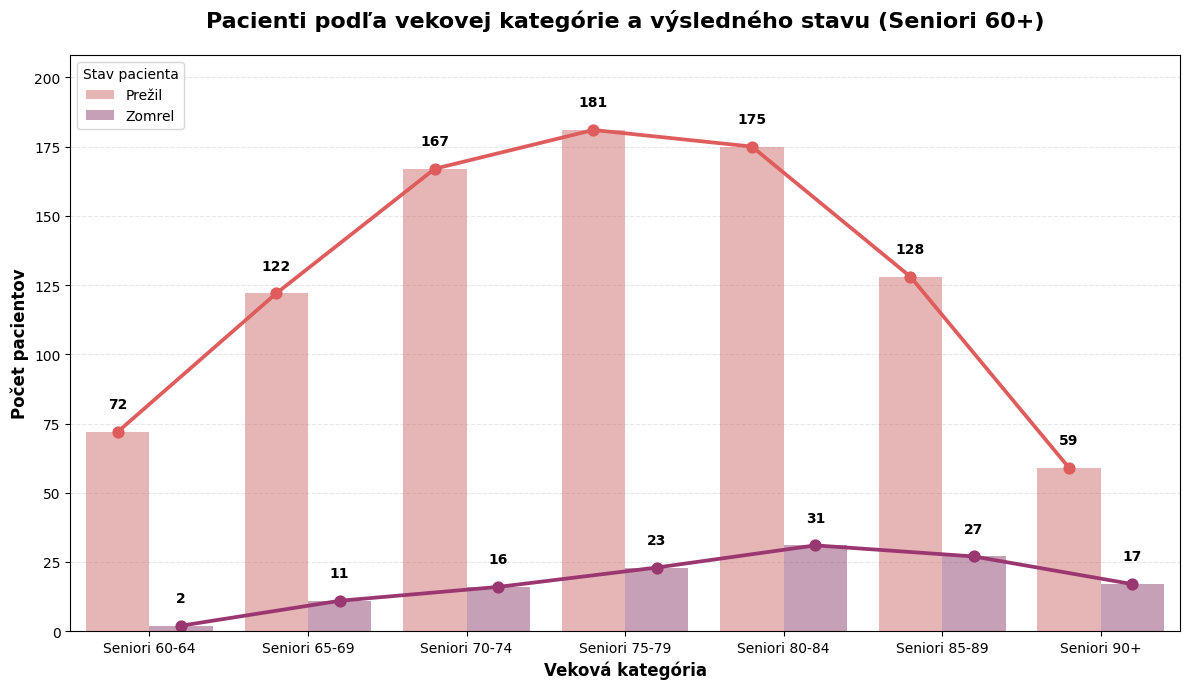

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

vek_col = first_existing_column(vlna_4, ["Vek"])
if vek_col is None:
    raise KeyError("V datasete sa nenašiel stĺpec 'Vek'.")

# --- 1. Základné rozdelenie veku ---
vek_kat = pd.cut(
    vlna_4[vek_col], 
    bins=[0, 18, 45, 60, 150], 
    labels=['deti_a_mládež', 'mladí_dospelí', 'stredný_vek', 'seniori'], 
    right=False
)

# Ak stĺpec už existuje z predošlého behu, vymažeme ho
if 'Vek_kategoria' in vlna_4.columns:
    vlna_4.drop(columns=['Vek_kategoria'], inplace=True)
    
vlna_4.insert(loc=vlna_4.columns.get_loc(vek_col) + 1, 
              column='Vek_kategoria', 
              value=vek_kat)

# --- 2. Detailné rozdelenie seniorov (60+) na 5-ročné intervaly ---
def detailni_seniori(row):
    vek = row[vek_col]
    if pd.isna(vek):
        return np.nan
    if vek < 60:
        return row['Vek_kategoria']
    elif 60 <= vek < 65:
        return 'Seniori 60-64'
    elif 65 <= vek < 70:
        return 'Seniori 65-69'
    elif 70 <= vek < 75:
        return 'Seniori 70-74'
    elif 75 <= vek < 80:
        return 'Seniori 75-79'
    elif 80 <= vek < 85:
        return 'Seniori 80-84'
    elif 85 <= vek < 90:
        return 'Seniori 85-89'
    else:
        return 'Seniori 90+'

vlna_4['Vek_kategoria'] = vlna_4.apply(detailni_seniori, axis=1)

# Vytvorenie binárnych stĺpcov z kategórie veku
vek_dummies = pd.get_dummies(vlna_4['Vek_kategoria'], prefix='Vek_kat').astype(bool)

# Určenie pozície pre vloženie (za Pohlavie)
if 'Pohlavie' in vlna_4.columns:
    pos = vlna_4.columns.get_loc('Pohlavie') + 1
else:
    pos = 0 

# Vloženie nových stĺpcov do datasetu
for col_name in reversed(vek_dummies.columns):
    if col_name in vlna_4.columns:
        vlna_4.drop(columns=[col_name], inplace=True)
    vlna_4.insert(loc=pos, column=col_name, value=vek_dummies[col_name])

# Odstránenie starých stĺpcov
stlpce_na_odstranenie = [
    vek_col, 'Vek_kategoria', 
    'Vek_kat_deti_a_mládež', 'Vek_kat_mladí_dospelí', 'Vek_kat_stredný_vek'
]
vlna_4.drop(columns=stlpce_na_odstranenie, inplace=True, errors='ignore')
print("Nadbytočné vekové kategórie (pod 60 r.) boli odstránené. V datasete pre pravidlá zostali len seniori.\n")

# Kontigenenčná tabuľka
vek_cols_senior = [col for col in vlna_4.columns if col.startswith('Vek_kat_Seniori')]

def urci_senior_kategoriu(row):
    for col in vek_cols_senior:
        if row[col] == True:
            return col.replace('Vek_kat_', '')
    return None  

docasna_kategoria = vlna_4.apply(urci_senior_kategoriu, axis=1)
vysledky_vek = pd.crosstab(docasna_kategoria, vlna_4['Zomrel'], dropna=True)
vysledky_vek.rename(columns={0: 'Prežil', 1: 'Zomrel'}, inplace=True)

if 'Zomrel' not in vysledky_vek.columns: vysledky_vek['Zomrel'] = 0
if 'Prežil' not in vysledky_vek.columns: vysledky_vek['Prežil'] = 0

vysledky_vek['Spolu'] = vysledky_vek['Prežil'] + vysledky_vek['Zomrel']
vysledky_vek['Úmrtnosť (%)'] = (vysledky_vek['Zomrel'] / vysledky_vek['Spolu'] * 100).round(2)
vysledky_vek = vysledky_vek.sort_index()

print("Prehľad mortality v rámci seniorských vekových kategórií:")
display(vysledky_vek)

# Vizualizácia grafu
plot_data = vysledky_vek[['Prežil', 'Zomrel']].reset_index()
nazov_indexu = plot_data.columns[0]
plot_data = plot_data.melt(id_vars=nazov_indexu, var_name='Stav', value_name='Počet')
plot_data.columns = ['Veková kategória', 'Stav', 'Počet']
plot_data['Veková kategória'] = plot_data['Veková kategória'].astype(str)

plt.figure(figsize=(12, 7))
hue_order = ['Prežil', 'Zomrel']


ax = sns.barplot(data=plot_data, 
                 x='Veková kategória', y='Počet', hue='Stav', 
                 hue_order=hue_order, palette='flare', alpha=0.5)


sns.pointplot(data=plot_data, 
              x='Veková kategória', y='Počet', hue='Stav', 
              hue_order=hue_order, palette='flare', 
              markers='o', linestyles='-', dodge=0.4, 
              errorbar=None, ax=ax)  


plt.ylim(0, plot_data['Počet'].max() * 1.15) 
ax.set_axisbelow(True) 


plt.title('Pacienti podľa vekovej kategórie a výsledného stavu (Seniori 60+)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Veková kategória', fontsize=12, fontweight='bold')
plt.ylabel('Počet pacientov', fontsize=12, fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Stav pacienta', loc='upper left')


for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 15), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Diskretizácia veku a príprava vekových kategórií

target_col = "Zomrel"
excluded_for_selection = {target_col}

# Kategorické a binárne atribúty -> Chi-kvadrát + Cramerovo V
cat_results = []
candidate_cat_cols = []

for col in vlna_4.columns:
    if col in excluded_for_selection:
        continue
        
    if str(col).startswith("Vek_kat_"):
        candidate_cat_cols.append(col)
        continue

    as_bool = safe_bool_series(vlna_4[col])
    if as_bool is not None:
        candidate_cat_cols.append(col)
        continue

    if (pd.api.types.is_object_dtype(vlna_4[col]) or 
        pd.api.types.is_categorical_dtype(vlna_4[col]) or
        vlna_4[col].nunique(dropna=True) <= 10):
        candidate_cat_cols.append(col)

candidate_cat_cols = list(dict.fromkeys(candidate_cat_cols))

for col in candidate_cat_cols:
    temp = vlna_4[[col, target_col]].copy().dropna()
    if temp.empty or temp[col].nunique() < 2 or temp[target_col].nunique() < 2:
        continue

    contingency = pd.crosstab(temp[col], temp[target_col])
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue

    chi2, p, _, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denom = min((kcorr - 1), (rcorr - 1))
    cramers_v = np.sqrt(phi2corr / denom) if denom > 0 else 0.0

    cat_results.append({
        "Atribút": col,
        "Typ": "kategorický/binárny",
        "Chi2": chi2,
        "P_hodnota": p,
        "Cramerovo_V": cramers_v
    })

cat_selection_df = pd.DataFrame(cat_results).sort_values(
    by=["Cramerovo_V", "Chi2"], ascending=False
) if cat_results else pd.DataFrame(columns=["Atribút", "Typ", "Chi2", "P_hodnota", "Cramerovo_V"])

# Numerické atribúty - Spearman 
numeric_candidates = [
    col for col in vlna_4.select_dtypes(include=[np.number]).columns
    if col not in {target_col} 
    
]

num_results = []
for col in numeric_candidates:
    temp = vlna_4[[col, target_col]].dropna()
    if temp.empty or temp[col].nunique() < 2:
        continue
    corr, p = spearmanr(temp[col], temp[target_col])
    if pd.isna(corr):
        continue
    num_results.append({
        "Atribút": col,
        "Typ": "numerický",
        "Spearman_abs": abs(float(corr)),
        "P_hodnota": float(p) if pd.notna(p) else np.nan
    })

num_selection_df = pd.DataFrame(num_results).sort_values(
    by=["Spearman_abs", "P_hodnota"], ascending=[False, True]
) if num_results else pd.DataFrame(columns=["Atribút", "Typ", "Spearman_abs", "P_hodnota"])

display(cat_selection_df.head(20))
display(num_selection_df.head(20))

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_34328/2810998290.py:24: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(vlna_4[col]) or
/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_34328/2810998290.py:24: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(vlna_4[col]) or
/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_34328/2810998290.py:24: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(vlna_4[col]) or
/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_34328/2810998290.py:24: DeprecationWarning: is_categorical_dtype is deprecated and will be remo

,Atribút,Typ,Chi2,P_hodnota,Cramerovo_V
16,Renálne ochorenia,kategorický/binárny,56.517008,5.571439e-14,0.210744
37,84090 | DEXAMED 6,kategorický/binárny,35.795096,2.191989e-09,0.166840
65,26846 OXANTIL,kategorický/binárny,34.567340,4.117571e-09,0.163870
48,45954 Ceftriaxon,kategorický/binárny,25.248364,5.040230e-07,0.139277
14,Kardiovaskulárne ochorenia,kategorický/binárny,24.354573,8.013626e-07,0.136686
47,35715 Azithromycin,kategorický/binárny,16.299735,5.407151e-05,0.110631
18,Onkologické ochorenia,kategorický/binárny,13.905084,1.922777e-04,0.101604
34,92973 ALPHA D3,kategorický/binárny,12.620142,3.816123e-04,0.096413
8,Vek_kat_Seniori 90+,kategorický/binárny,11.607648,6.568116e-04,0.092117
64,24949 CODEIN,kategorický/binárny,10.889368,9.671781e-04,0.088943


,Atribút,Typ,Spearman_abs,P_hodnota
102,S-IL6 last,numerický,0.401783,9.960620e-50
54,S-CRP last,numerický,0.363987,1.752511e-40
66,S-Urea last,numerický,0.363860,1.874099e-40
170,NE/LY(NLR) last,numerický,0.351973,8.589780e-38
171,NE/LY(NLR) min,numerický,0.320579,2.708760e-31
55,S-CRP min,numerický,0.311708,1.364667e-29
174,D-dimér HS last,numerický,0.303806,4.011150e-28
68,S-Urea max,numerický,0.301469,1.068798e-27
104,S-IL6 max,numerický,0.295210,1.411388e-26
180,S-PBNP last,numerický,0.293705,2.600643e-26


In [12]:
# Výber štatisticky významných atribútov

import pandas as pd

# Výber kategorických/binárnych atribútov (Chí-kvadrát) 
selected_cat = []
if not cat_selection_df.empty:
    # Vyberieme  (p < 0.05) zoradené podľa Cramerovho V
    selected_cat = cat_selection_df[
        (cat_selection_df["P_hodnota"] < 0.05)
    ].sort_values("Cramerovo_V", ascending=False)["Atribút"].tolist()

# Výber unikátnych 'last' numerických markerov (Spearman) 
selected_num_raw = []
if not num_selection_df.empty:
    
    selected_num_raw = num_selection_df[
        (num_selection_df["P_hodnota"] < 0.05) & 
        (num_selection_df["Atribút"].str.contains('last', case=False))
    ].sort_values("Spearman_abs", ascending=False)["Atribút"].tolist()


senior_age_cols = [col for col in vlna_4.columns if str(col).startswith("Vek_kat_Seniori")]
for age_col in senior_age_cols:
    if age_col not in selected_cat:
        selected_cat.append(age_col)


selected_cat = list(dict.fromkeys(selected_cat))[:15]
selected_num = selected_num_raw[:15]

print(f"Vybraných {len(selected_cat)} kategorických atribútov.")
print(f"Vybraných {len(selected_num)} unikátnych 'last' markerov.")

df_items = pd.DataFrame(index=vlna_4.index)

# Spracovanie kategorických a binárnych atribútov 
for col in selected_cat:
    
    if str(col).startswith("Vek_kat_Seniori"):
        pretty_name = str(col).replace('Vek_kat_', '')
        df_items[pretty_name] = vlna_4[col].fillna(False).astype(bool)
        continue

    as_bool = safe_bool_series(vlna_4[col])
    if as_bool is not None:
        df_items[str(col)] = as_bool
    else:
        
        dummies = pd.get_dummies(vlna_4[col].astype(str), prefix=str(col))
        dummies = dummies[[c for c in dummies.columns if not c.endswith("_nan")]]
        for dcol in dummies.columns:
            df_items[dcol] = dummies[dcol].astype(bool)

# Binarizácia 
medical_cutoffs = {
    "S-CRP": 5.0, "S-IL6": 7.0, "D-dimér HS": 0.5, "S-AST": 0.85, 
    "S-ALT": 0.85, "S-Urea": 8.3, "S-Kreat": 104.0, "S-FER": 300.0, 
    "WBC": 10.0, "PLT": 400.0, "NE/LY(NLR)": 3.1, "S-PBNP": 300.0, 
    "S-Gluk": 5.6, "S-Chol": 5.0, "Fib": 4.0
}

for col in selected_num:
    s = vlna_4[col]
    
    base_param = str(col).replace(' last', '').strip()
    
    # Určenie threshold 
    threshold = medical_cutoffs.get(base_param, s.quantile(0.75))
    
    item_name = f"{base_param}_Vysoke"
    df_items[item_name] = (s > threshold).fillna(False).astype(bool)


df_items["Zomrel"] = vlna_4["Zomrel"].astype(bool)

min_item_support = 0.01
item_supports = df_items.mean()
keep_cols = item_supports[item_supports >= min_item_support].index.tolist()

if "Zomrel" not in keep_cols:
    keep_cols.append("Zomrel")
    
df_final = df_items[keep_cols].copy()

print(f"\nTransakčná matica pripravená. Počet atribútov: {df_final.shape[1]}")
print("Ukážka vyčištených názvov stĺpcov:")
print(df_final.columns.tolist())
display(df_final.head())

Vybraných 15 kategorických atribútov.
Vybraných 15 unikátnych 'last' markerov.

Transakčná matica pripravená. Počet atribútov: 32
Ukážka vyčištených názvov stĺpcov:
['Renálne ochorenia', '84090 | DEXAMED 6', '26846 OXANTIL', '45954 Ceftriaxon', 'Kardiovaskulárne ochorenia', '35715 Azithromycin', 'Onkologické ochorenia', '92973 ALPHA D3', 'Seniori 90+', '24949 CODEIN ', '84370 LAGOSA', 'Seniori 85-89', 'Hypertenzia', 'CLEXANE', 'Pohlavie_Muž', 'Pohlavie_Žena', 'S-IL6_Vysoke', 'S-CRP_Vysoke', 'S-Urea_Vysoke', 'NE/LY(NLR)_Vysoke', 'D-dimér HS_Vysoke', 'S-PBNP_Vysoke', 'Neu abs_Vysoke', 'Ly abs_Vysoke', 'S-LD_Vysoke', 'S-Kreat_Vysoke', 'S-Alb_Vysoke', 'S-Gluk_Vysoke', 'Eo abs_Vysoke', 'WBC_Vysoke', 'S-IgG_Vysoke', 'Zomrel']


,Renálne ochorenia,84090 | DEXAMED 6,26846 OXANTIL,45954 Ceftriaxon,Kardiovaskulárne ochorenia,35715 Azithromycin,Onkologické ochorenia,92973 ALPHA D3,Seniori 90+,24949 CODEIN,...,Neu abs_Vysoke,Ly abs_Vysoke,S-LD_Vysoke,S-Kreat_Vysoke,S-Alb_Vysoke,S-Gluk_Vysoke,Eo abs_Vysoke,WBC_Vysoke,S-IgG_Vysoke,Zomrel
0,True,False,True,True,True,False,False,True,False,False,...,True,False,False,False,False,True,False,True,False,True
1,False,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,True,True,False
2,True,False,False,False,True,False,False,True,False,True,...,False,False,False,False,False,True,True,False,True,False
3,True,True,True,False,True,False,False,False,False,True,...,True,False,True,True,False,True,False,True,False,True
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
# Vytvorenie transakčnej matice pre asociačné pravidlá

min_sup = 0.015       
min_conf = 0.45      
min_lift = 1.30     
max_rule_len = 4     

frequent_itemsets = apriori(
    df_final,
    min_support=min_sup,
    use_colnames=True,
    max_len=max_rule_len
)

print("Počet frequent itemsets:", len(frequent_itemsets))
display(frequent_itemsets.sort_values("support", ascending=False).head(20))


Počet frequent itemsets: 18667


,support,itemsets
4,0.766587,(Kardiovaskulárne ochorenia)
20,0.733014,(D-dimér HS_Vysoke)
17,0.732214,(S-CRP_Vysoke)
12,0.730616,(Hypertenzia)
21,0.729017,(S-PBNP_Vysoke)
150,0.726619,"(Kardiovaskulárne ochorenia, Hypertenzia)"
16,0.615508,(S-IL6_Vysoke)
159,0.612310,"(Kardiovaskulárne ochorenia, S-PBNP_Vysoke)"
158,0.592326,"(D-dimér HS_Vysoke, Kardiovaskulárne ochorenia)"
155,0.585931,"(S-CRP_Vysoke, Kardiovaskulárne ochorenia)"


In [14]:
# Generovanie frekventovaných množín algoritmom Apriori

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_lift)

rules_filtered = rules[
    (rules["consequents"].apply(lambda x: x == frozenset({"Zomrel"}))) &
    (rules["antecedents"].apply(lambda x: "Zomrel" not in x and "Vysledok_Zomrel" not in x)) &
    (rules["confidence"] >= min_conf) &
    (rules["lift"] >= min_lift)
].copy()

rules_filtered["antecedent_len"] = rules_filtered["antecedents"].apply(len)
rules_filtered = rules_filtered[
    (rules_filtered["antecedent_len"] >= 1) &
    (rules_filtered["antecedent_len"] <= max_rule_len)
]

rules_filtered["antecedent_str"] = rules_filtered["antecedents"].apply(
    lambda x: " + ".join(sorted(list(x)))
)
rules_filtered["consequent_str"] = rules_filtered["consequents"].apply(
    lambda x: " + ".join(sorted(list(x)))
)

rules_filtered = rules_filtered.drop_duplicates(
    subset=["antecedent_str", "consequent_str"]
).sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print(f"Našlo sa {len(rules_filtered)} pravidiel po filtrovaní.")
print(
    f"Thresholdy: min_support={min_sup}, min_confidence={min_conf}, "
    f"min_lift={min_lift}, max_len={max_rule_len}"
)

rules_table = rules_filtered[[
    "antecedent_str", "consequent_str", "antecedent support",
    "consequent support", "support", "confidence", "lift",
    "leverage", "conviction"
]].copy()

rules_table.columns = [
    "Antecedent", "Consequent", "Antecedent support",
    "Consequent support", "Support", "Confidence",
    "Lift", "Leverage", "Conviction"
]

display(rules_table.head(30))


Našlo sa 42 pravidiel po filtrovaní.
Thresholdy: min_support=0.015, min_confidence=0.45, min_lift=1.3, max_len=4


,Antecedent,Consequent,Antecedent support,Consequent support,Support,Confidence,Lift,Leverage,Conviction
0,CLEXANE + Neu abs_Vysoke + S-Kreat_Vysoke,Zomrel,0.044764,0.102318,0.024780,0.553571,5.410296,0.020200,2.010807
1,26846 OXANTIL + Neu abs_Vysoke + S-Kreat_Vysoke,Zomrel,0.035971,0.102318,0.019185,0.533333,5.212500,0.015504,1.923604
2,26846 OXANTIL + S-Kreat_Vysoke + S-LD_Vysoke,Zomrel,0.037570,0.102318,0.019984,0.531915,5.198637,0.016140,1.917775
3,CLEXANE + S-Kreat_Vysoke + WBC_Vysoke,Zomrel,0.045564,0.102318,0.023981,0.526316,5.143914,0.019319,1.895106
4,Onkologické ochorenia + S-IL6_Vysoke + S-Urea_...,Zomrel,0.031974,0.102318,0.016787,0.525000,5.131055,0.013515,1.889857
5,26846 OXANTIL + S-Kreat_Vysoke + WBC_Vysoke,Zomrel,0.036771,0.102318,0.019185,0.521739,5.099185,0.015422,1.876971
6,84090 | DEXAMED 6 + S-Kreat_Vysoke + S-LD_Vysoke,Zomrel,0.049560,0.102318,0.025580,0.516129,5.044355,0.020509,1.855209
7,Neu abs_Vysoke + S-IL6_Vysoke + S-Kreat_Vysoke,Zomrel,0.065548,0.102318,0.032774,0.500000,4.886719,0.026067,1.795364
8,84090 | DEXAMED 6 + CLEXANE + S-Kreat_Vysoke,Zomrel,0.051159,0.102318,0.025580,0.500000,4.886719,0.020345,1.795364
9,S-Gluk_Vysoke + S-Kreat_Vysoke + S-LD_Vysoke,Zomrel,0.059952,0.102318,0.029576,0.493333,4.821563,0.023442,1.771741


In [15]:
# Filtrovanie pravidiel zameraných na úmrtie

if not rules_filtered.empty:
    print(f"{'#'*60}")
    print(f"{'ZOZNAM ASOCIAČNÝCH PRAVIDIEL':^60}")
    print(f"{'#'*60}\n")

    
    for i, row in rules_filtered.iterrows():
        
        antecedents = ", ".join(list(row['antecedents']))
        consequents = ", ".join(list(row['consequents']))
        
        
        print(f"Pravidlo č. {i+1}:")
        print(f"  IF {antecedents}")
        print(f"  THEN {consequents}")
        
        # Výpis metrík
        #print(f"  Metriky: ")
        #print(f"    - Podpora (Support):    {row['support']:.4f}")
        #print(f"    - Spoľahlivosť (Conf.): {row['confidence']:.4f}")
        #print(f"    - Zdvih (Lift):         {row['lift']:.4f}")
        #print("-" * 60)
else:
    print("Neboli nájdené žiadne pravidlá na výpis.")

############################################################
                ZOZNAM ASOCIAČNÝCH PRAVIDIEL                
############################################################

Pravidlo č. 1:
  IF Neu abs_Vysoke, CLEXANE, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 2:
  IF Neu abs_Vysoke, 26846 OXANTIL, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 3:
  IF 26846 OXANTIL, S-Kreat_Vysoke, S-LD_Vysoke
  THEN Zomrel
Pravidlo č. 4:
  IF CLEXANE, S-Kreat_Vysoke, WBC_Vysoke
  THEN Zomrel
Pravidlo č. 5:
  IF S-IL6_Vysoke, S-Urea_Vysoke, Onkologické ochorenia
  THEN Zomrel
Pravidlo č. 6:
  IF 26846 OXANTIL, S-Kreat_Vysoke, WBC_Vysoke
  THEN Zomrel
Pravidlo č. 7:
  IF S-Kreat_Vysoke, S-LD_Vysoke, 84090 | DEXAMED 6
  THEN Zomrel
Pravidlo č. 8:
  IF Neu abs_Vysoke, S-IL6_Vysoke, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 9:
  IF CLEXANE, S-Kreat_Vysoke, 84090 | DEXAMED 6
  THEN Zomrel
Pravidlo č. 10:
  IF S-Gluk_Vysoke, S-Kreat_Vysoke, S-LD_Vysoke
  THEN Zomrel
Pravidlo č. 11:
  IF S-Kreat_Vysoke, S-

In [16]:
if not rules_filtered.empty:
    print(f"{'#'*60}")
    print(f"{'ZOZNAM ASOCIAČNÝCH PRAVIDIEL':^60}")
    print(f"{'#'*60}\n")

    for i, row in rules_filtered.iterrows():
        
        antecedents = ", ".join(list(row['antecedents']))
        consequents = ", ".join(list(row['consequents']))
        
        
        print(f"Pravidlo č. {i+1}:")
        print(f"  IF {antecedents}")
        print(f"  THEN {consequents}")
        
        # Výpis metrík
        #print(f"  Metriky: ")
        #print(f"    - Podpora (Support):    {row['support']:.4f}")
        #print(f"    - Spoľahlivosť (Conf.): {row['confidence']:.4f}")
        #print(f"    - Zdvih (Lift):         {row['lift']:.4f}")
        #print("-" * 60)
else:
    print("Neboli nájdené žiadne pravidlá na výpis.")

############################################################
                ZOZNAM ASOCIAČNÝCH PRAVIDIEL                
############################################################

Pravidlo č. 1:
  IF Neu abs_Vysoke, CLEXANE, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 2:
  IF Neu abs_Vysoke, 26846 OXANTIL, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 3:
  IF 26846 OXANTIL, S-Kreat_Vysoke, S-LD_Vysoke
  THEN Zomrel
Pravidlo č. 4:
  IF CLEXANE, S-Kreat_Vysoke, WBC_Vysoke
  THEN Zomrel
Pravidlo č. 5:
  IF S-IL6_Vysoke, S-Urea_Vysoke, Onkologické ochorenia
  THEN Zomrel
Pravidlo č. 6:
  IF 26846 OXANTIL, S-Kreat_Vysoke, WBC_Vysoke
  THEN Zomrel
Pravidlo č. 7:
  IF S-Kreat_Vysoke, S-LD_Vysoke, 84090 | DEXAMED 6
  THEN Zomrel
Pravidlo č. 8:
  IF Neu abs_Vysoke, S-IL6_Vysoke, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 9:
  IF CLEXANE, S-Kreat_Vysoke, 84090 | DEXAMED 6
  THEN Zomrel
Pravidlo č. 10:
  IF S-Gluk_Vysoke, S-Kreat_Vysoke, S-LD_Vysoke
  THEN Zomrel
Pravidlo č. 11:
  IF S-Kreat_Vysoke, S-

In [17]:

vlna_4['S-CRP min'].describe()
vlna_4['S-IL6 max'].describe()

count    1251.000000
mean      174.807012
std       467.046673
min       -59.719338
25%        17.375000
50%        43.380000
75%       123.850000
max      4984.000000
Name: S-IL6 max, dtype: float64

In [18]:
# Prehľadný výpis nájdených pravidiel

if not rules_filtered.empty:
    out_name = "vysledne_pravidla.xlsx"
    rules_table.to_excel(out_name, index=False)
    print(f"Výsledná tabuľka pravidiel bola uložená do: {out_name}")
else:
    print("Nie sú žiadne pravidlá na export.")


Výsledná tabuľka pravidiel bola uložená do: vysledne_pravidla.xlsx


In [19]:
from IPython.display import display

zoznam_komorbidit = [
    'Hypertenzia', 'Diabetes', 'Kardiovaskulárne', 
    'Obezita', 'Chronické respiračné', 'Onkologické', 'Renálne'
]

try:
    df_pravidla = rules_table.copy()
except NameError:
    df_pravidla = rules_filtered.copy()


dostupne_stlpce = df_pravidla.columns.tolist()

if 'antecedents' in dostupne_stlpce:
    col_ant = 'antecedents'
    col_con = 'consequents'
elif 'Predpoklad' in dostupne_stlpce:
    col_ant = 'Predpoklad'
    col_con = 'Následok' if 'Následok' in dostupne_stlpce else 'Dôsledok'
else:
    
    col_ant = dostupne_stlpce[0]
    col_con = dostupne_stlpce[1]


col_sup = next((c for c in dostupne_stlpce if 'support' in c.lower()), 'support')
col_conf = next((c for c in dostupne_stlpce if 'confidence' in c.lower() or 'spolahlivost' in c.lower()), 'confidence')
col_lift = next((c for c in dostupne_stlpce if 'lift' in c.lower()), 'lift')


def obsahuje_komorbiditu(antecedent_str):
    text_pravidla = str(antecedent_str)
    for komorbidita in zoznam_komorbidit:
        if komorbidita.lower() in text_pravidla.lower():
            return True
    return False

df_pravidla['S_Komorbiditou'] = df_pravidla[col_ant].apply(obsahuje_komorbiditu)


pravidla_komorbidity = df_pravidla[df_pravidla['S_Komorbiditou'] == True]
pravidla_ostatne = df_pravidla[df_pravidla['S_Komorbiditou'] == False]

# Zoradenie podľa najsilnejších metrík
sort_cols = [col_lift, col_conf]
vypis_cols = [col_ant, col_con, col_sup, col_conf, col_lift]

top_s_komorbiditou = pravidla_komorbidity.sort_values(by=sort_cols, ascending=[False, False]).head(10)
top_bez_komorbidity = pravidla_ostatne.sort_values(by=sort_cols, ascending=[False, False]).head(10)

# =================================================================
# VÝPIS VÝSLEDKOV PRE DIPLOMOVÚ PRÁCU


print("==================================================================")
print("10 NAJZAUJÍMAVEJŠÍCH PRAVIDIEL OBSAHUJÚCICH KOMORBIDITU")
print("==================================================================")
if not top_s_komorbiditou.empty:
    display(top_s_komorbiditou[vypis_cols])
else:
    print("Nenašli sa žiadne pravidlá s definovanými komorbiditami.")

print("\n==================================================================")
print("10 NAJSILNEJŠÍCH PRAVIDIEL BEZ KOMORBIDÍT")
print("==================================================================")
if not top_bez_komorbidity.empty:
    display(top_bez_komorbidity[vypis_cols])
else:
    print("Nenašli sa žiadne pravidlá bez komorbidít.")

10 NAJZAUJÍMAVEJŠÍCH PRAVIDIEL OBSAHUJÚCICH KOMORBIDITU


,Antecedent,Consequent,Antecedent support,Confidence,Lift
4,Onkologické ochorenia + S-IL6_Vysoke + S-Urea_...,Zomrel,0.031974,0.525000,5.131055
14,Onkologické ochorenia + S-IL6_Vysoke + WBC_Vysoke,Zomrel,0.035172,0.477273,4.664595
19,Onkologické ochorenia + S-IL6_Vysoke + S-LD_Vy...,Zomrel,0.037570,0.468085,4.574801
21,Neu abs_Vysoke + Onkologické ochorenia + S-IL6...,Zomrel,0.035971,0.466667,4.560938
22,Onkologické ochorenia + S-CRP_Vysoke + S-Urea_...,Zomrel,0.035971,0.466667,4.560938
23,D-dimér HS_Vysoke + Onkologické ochorenia + S-...,Zomrel,0.035971,0.466667,4.560938
30,D-dimér HS_Vysoke + Onkologické ochorenia + S-...,Zomrel,0.038369,0.458333,4.479492
33,D-dimér HS_Vysoke + Neu abs_Vysoke + Onkologic...,Zomrel,0.036771,0.456522,4.461787
34,D-dimér HS_Vysoke + Onkologické ochorenia + WB...,Zomrel,0.036771,0.456522,4.461787
35,Neu abs_Vysoke + Onkologické ochorenia + WBC_V...,Zomrel,0.036771,0.456522,4.461787



10 NAJSILNEJŠÍCH PRAVIDIEL BEZ KOMORBIDÍT


,Antecedent,Consequent,Antecedent support,Confidence,Lift
0,CLEXANE + Neu abs_Vysoke + S-Kreat_Vysoke,Zomrel,0.044764,0.553571,5.410296
1,26846 OXANTIL + Neu abs_Vysoke + S-Kreat_Vysoke,Zomrel,0.035971,0.533333,5.212500
2,26846 OXANTIL + S-Kreat_Vysoke + S-LD_Vysoke,Zomrel,0.037570,0.531915,5.198637
3,CLEXANE + S-Kreat_Vysoke + WBC_Vysoke,Zomrel,0.045564,0.526316,5.143914
5,26846 OXANTIL + S-Kreat_Vysoke + WBC_Vysoke,Zomrel,0.036771,0.521739,5.099185
6,84090 | DEXAMED 6 + S-Kreat_Vysoke + S-LD_Vysoke,Zomrel,0.049560,0.516129,5.044355
7,Neu abs_Vysoke + S-IL6_Vysoke + S-Kreat_Vysoke,Zomrel,0.065548,0.500000,4.886719
8,84090 | DEXAMED 6 + CLEXANE + S-Kreat_Vysoke,Zomrel,0.051159,0.500000,4.886719
9,S-Gluk_Vysoke + S-Kreat_Vysoke + S-LD_Vysoke,Zomrel,0.059952,0.493333,4.821563
10,S-Kreat_Vysoke + S-LD_Vysoke + WBC_Vysoke,Zomrel,0.049560,0.483871,4.729083


In [20]:
import pandas as pd
from IPython.display import display


hladane_pravidlo = "NE/LY(NLR) min_Vysoke + S-Urea last_Vysoke + Seniori 80-84"


podmienky = [p.strip() for p in hladane_pravidlo.split('+')]


referencne_normy = {
    "S-CRP": "0.0 - 5.0 mg/L",
    "S-IL6": "0.0 - 7.0 pg/mL",
    "D-dimér HS": "0.0 - 0.5 mg/L",
    "S-Urea": "2.5 - 8.3 mmol/L",
    "S-Kreat": "62 - 104 umol/L",
    "NE/LY(NLR)": "1.0 - 3.1 (pomer)",
    "S-PBNP": "0 - 300 pg/mL",
    "S-Gluk": "3.3 - 5.6 mmol/L",
    "WBC": "4.0 - 10.0 10^9/L",
    "PLT": "150 - 400 10^9/L",
    "Fib": "2.0 - 4.0 g/L"
}


maska_pacientov = df_items['Zomrel'] == True
for p in podmienky:
    if p in df_items.columns:
        maska_pacientov = maska_pacientov & (df_items[p] == True)

indexy_pacientov = df_items[maska_pacientov].index
pocet_pacientov = len(indexy_pacientov)

print(f"==========================================================")
print(f"ANALÝZA PRAVIDLA: {hladane_pravidlo} -> Zomrel")
print(f"==========================================================")

if pocet_pacientov > 0:
    
    original_stlpce = []
    if 'Vek' in vlna_4.columns: original_stlpce.append('Vek')
        
    for p in podmienky:
        orig_nazov = p.replace('_Vysoke', '').replace('_Nizke', '').strip()
        
        if orig_nazov in vlna_4.columns and orig_nazov not in original_stlpce:
            original_stlpce.append(orig_nazov)
    
    if len(original_stlpce) > 0:
        realne_data_pacientov = vlna_4.loc[indexy_pacientov, original_stlpce]
        
        # Tabuľka referenčných hodnôt 
        print("LEKÁRSKE REFERENČNÉ NORMY (Pre porovnanie):")
        normy_list = []
        for col in original_stlpce:
            base = col.replace(' last','').replace(' first','').replace(' min','').replace(' max','')
            normy_list.append({"Atribút": col, "Normálna hodnota (Zdravý človek)": referencne_normy.get(base, "Individuálne / Neudaná")})
        
        display(pd.DataFrame(normy_list).set_index("Atribút"))
        print("-" * 60)

       
        print("ŠTATISTIKA TEJTO SKUPINY PACIENTOV (Kritické stavy):")
        statistika = realne_data_pacientov.describe().loc[['mean', 'min', 'max']]
        statistika = statistika.rename(index={'mean': 'Priemer v skupine', 'min': 'Minimum v skupine', 'max': 'Maximum v skupine'})
        display(statistika.round(2))
        
        print("\n🩺 UKÁŽKA KONKRÉTNYCH PACIENTOV (Anonymizované ID):")
        display(realne_data_pacientov.head(5))
    else:
        print("Nenašli sa číselné údaje pre toto pravidlo.")
else:
    print("Žiadny pacient nespĺňa túto kombináciu podmienok.")

ANALÝZA PRAVIDLA: NE/LY(NLR) min_Vysoke + S-Urea last_Vysoke + Seniori 80-84 -> Zomrel
LEKÁRSKE REFERENČNÉ NORMY (Pre porovnanie):


,Normálna hodnota (Zdravý človek)
Atribút,
NE/LY(NLR) min,1.0 - 3.1 (pomer)
S-Urea last,2.5 - 8.3 mmol/L


------------------------------------------------------------
ŠTATISTIKA TEJTO SKUPINY PACIENTOV (Kritické stavy):


,NE/LY(NLR) min,S-Urea last
Priemer v skupine,10.11,15.86
Minimum v skupine,0.34,4.08
Maximum v skupine,75.74,45.13



🩺 UKÁŽKA KONKRÉTNYCH PACIENTOV (Anonymizované ID):


,NE/LY(NLR) min,S-Urea last
0,3.440000,11.240000
3,10.230000,30.400000
8,3.428198,6.848712
17,6.800000,16.920000
23,7.030000,9.250000


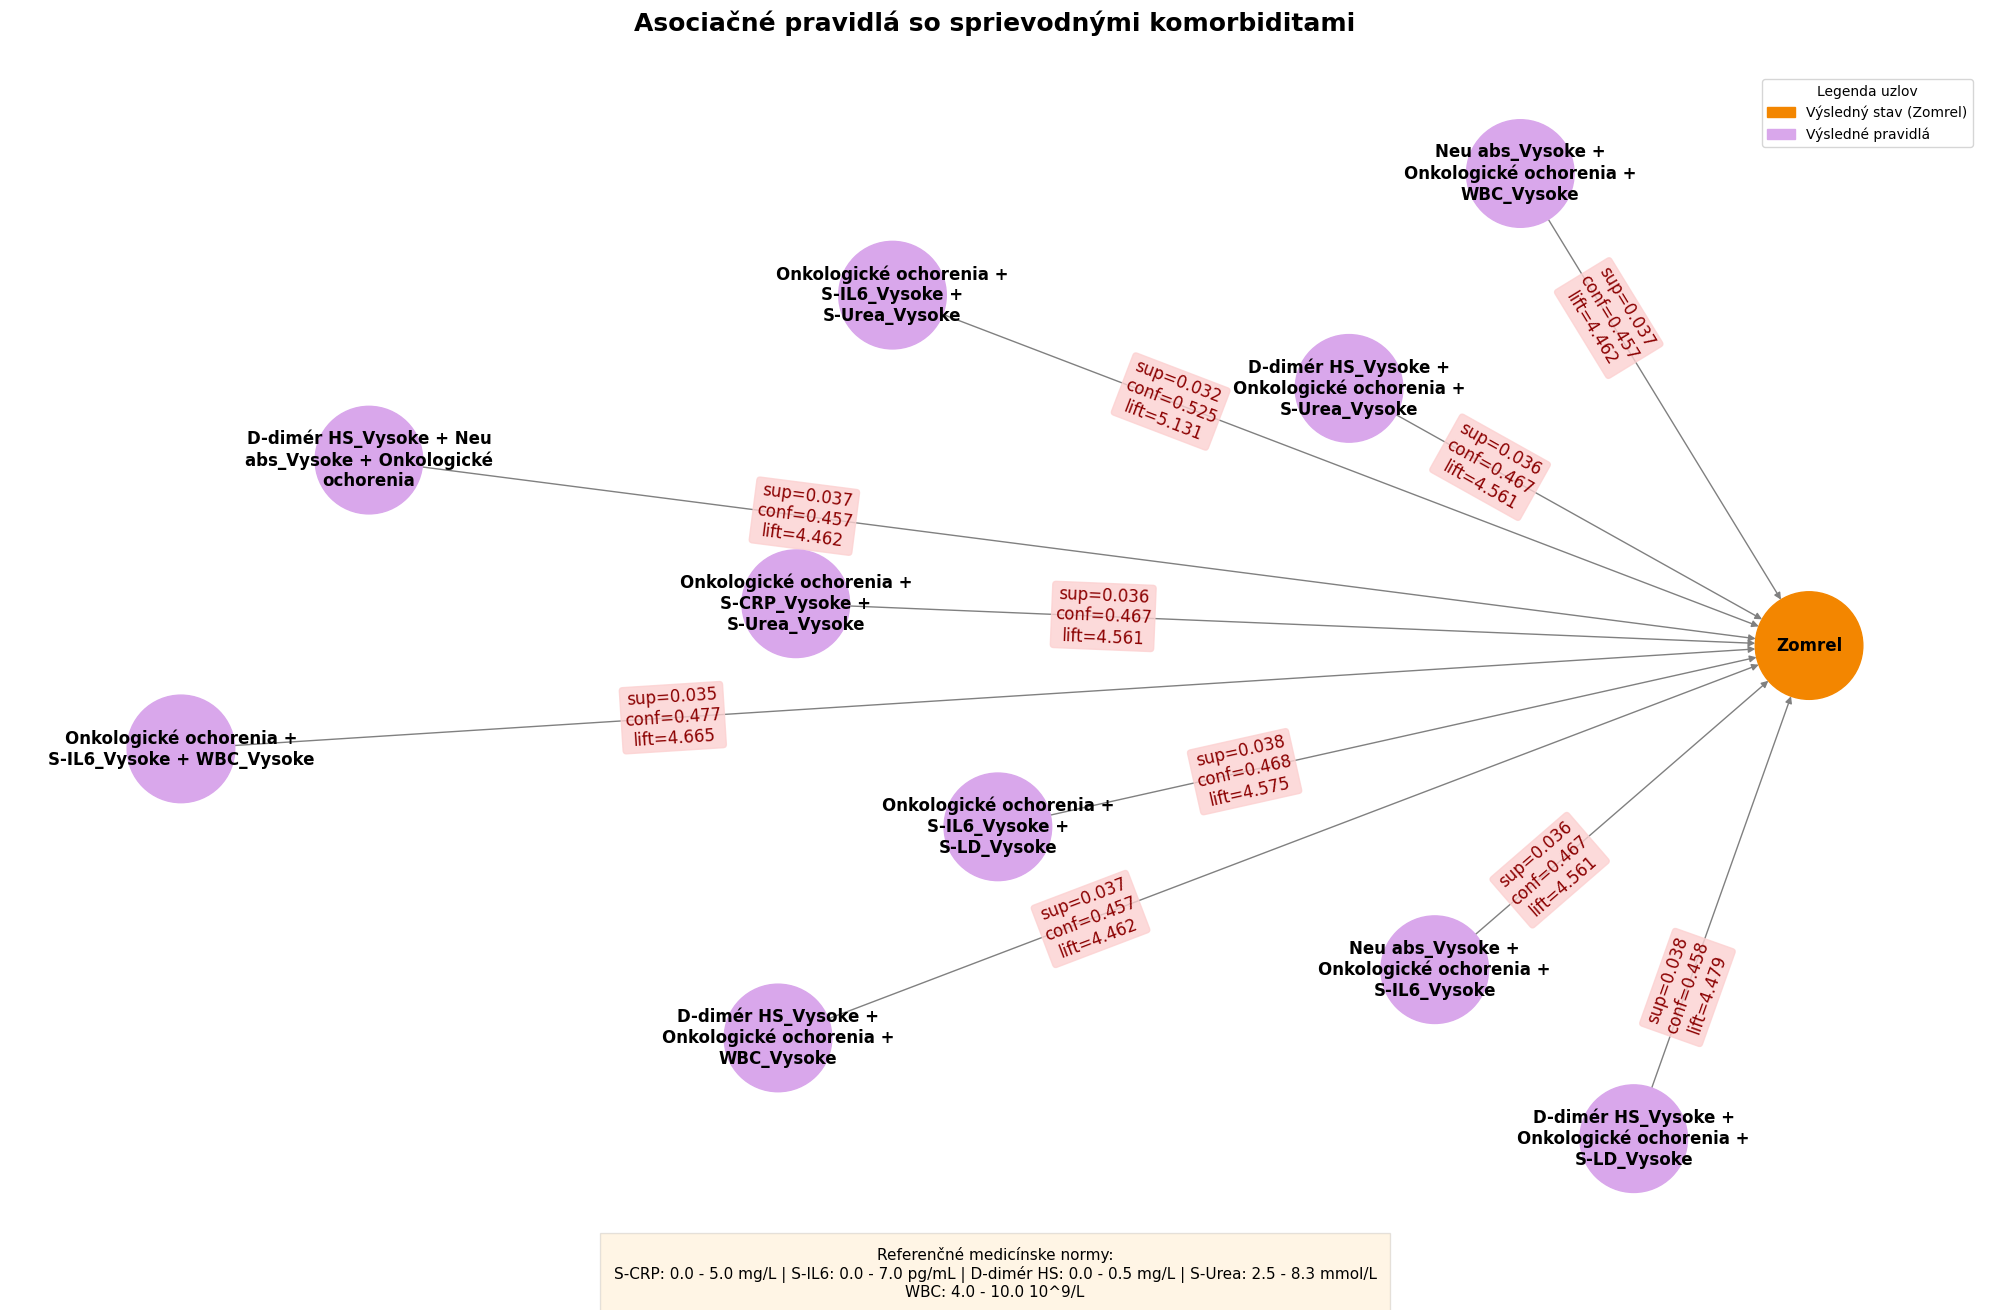

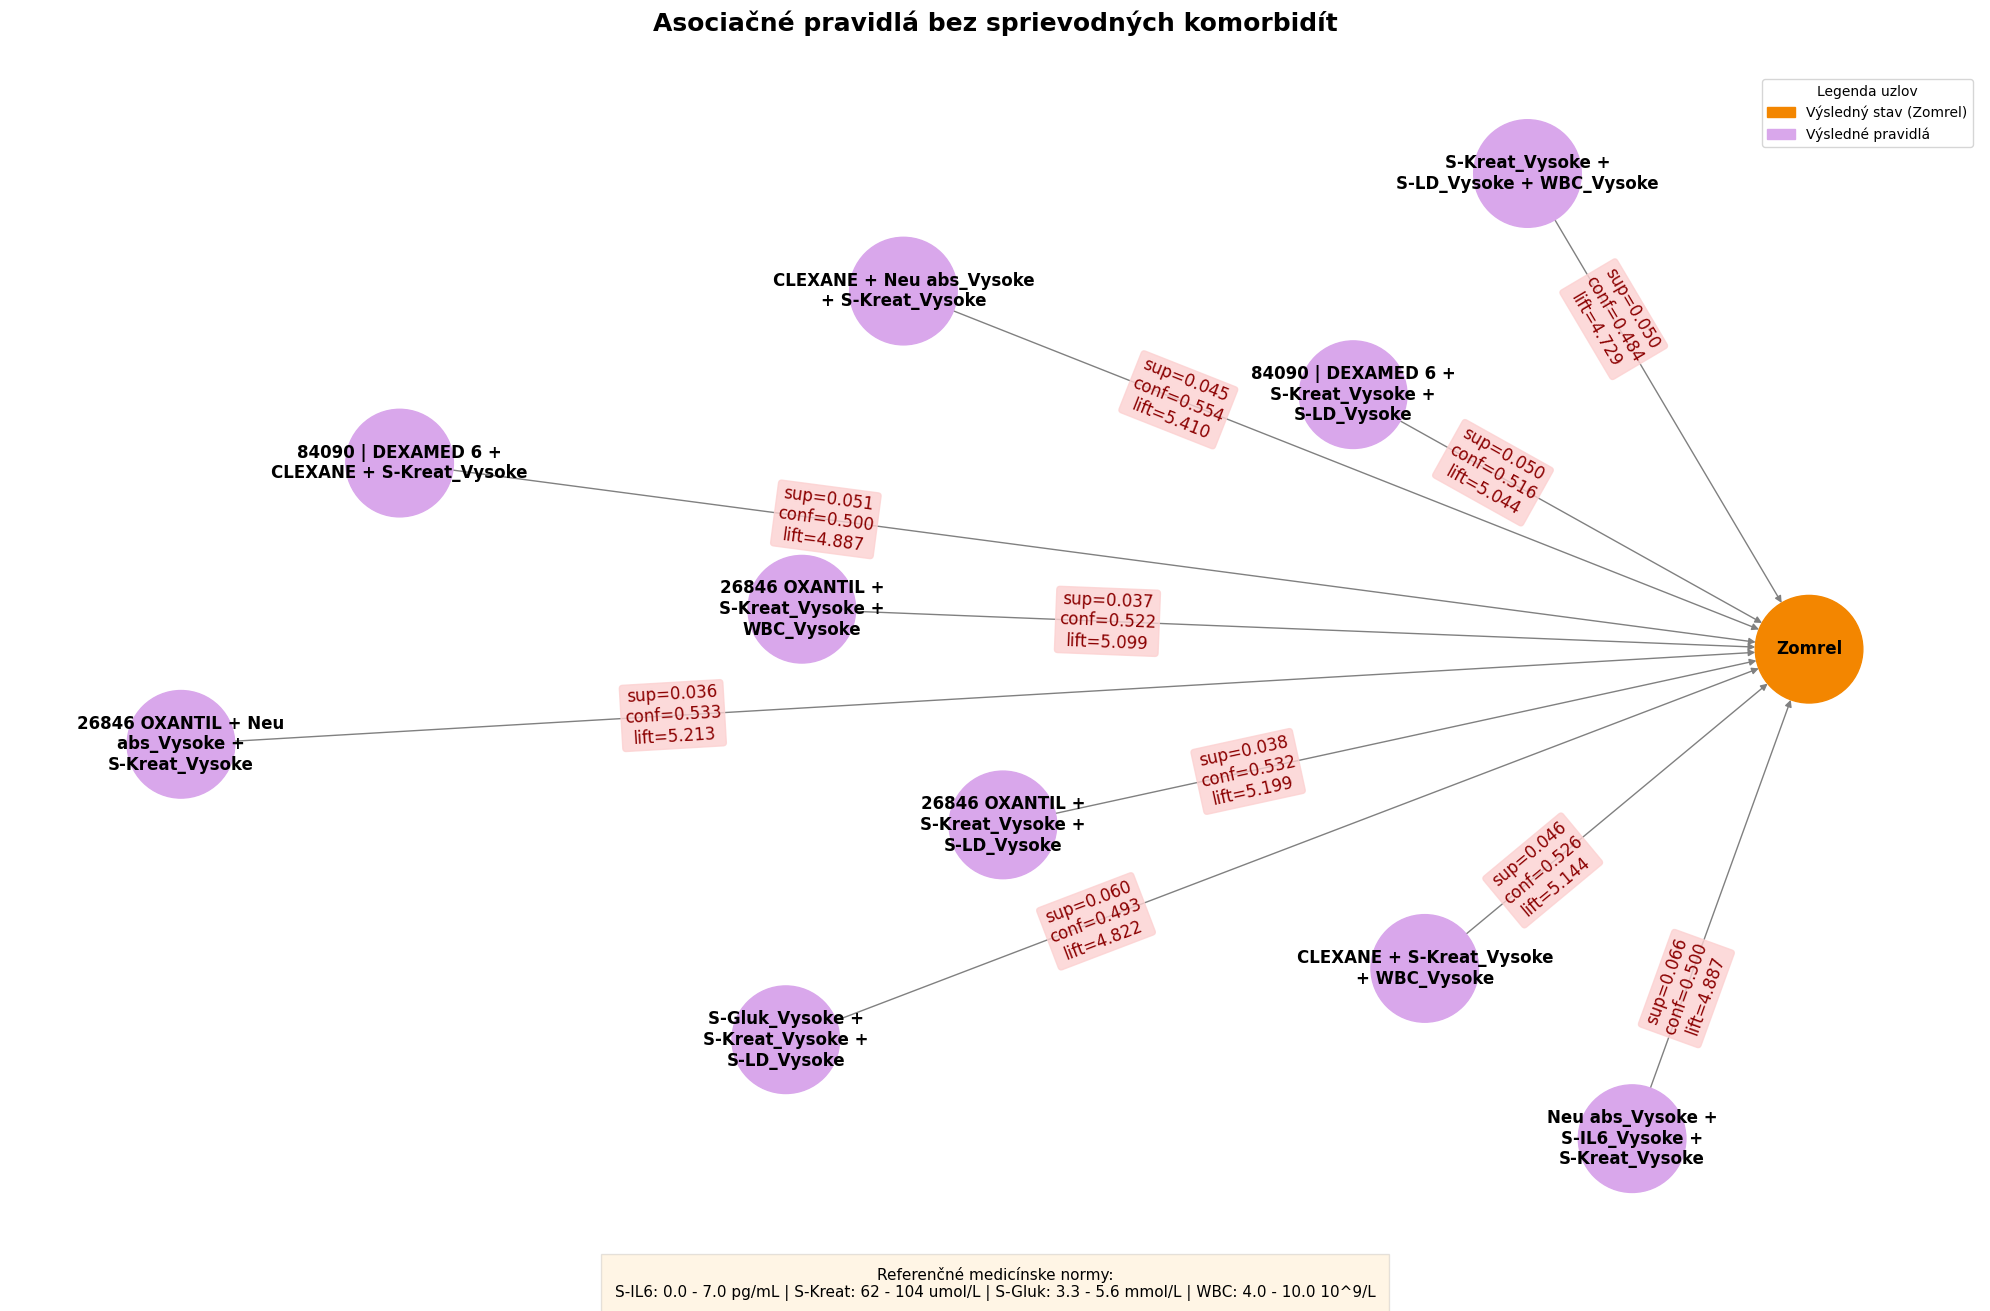

In [21]:
# Export výsledných pravidiel do Excelu

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap 

# Vykreslenie Sieťových grafov
def plot_custom_network(df, title, filename, normy):
    if df.empty:
        print(f"Tabuľka pre '{title}' je prázdna.")
        return

    
    fig, ax = plt.subplots(figsize=(20, 14))
    G = nx.DiGraph()
    parametre_v_grafe = set()

    for _, row in df.iterrows():
        ant = str(row["Antecedent"]).replace("frozenset({", "").replace("})", "").replace("'", "")
        con = str(row["Consequent"]).replace("frozenset({", "").replace("})", "").replace("'", "")
        
        for p in ant.split(" + "):
            parametre_v_grafe.add(p.replace("Vysoke", "").strip())

        label = f"sup={row.get('Antecedent support', 0):.3f}\nconf={row['Confidence']:.3f}\nlift={row['Lift']:.3f}"
        G.add_edge(ant, con, label=label, weight=row["Lift"])

    
    pos = nx.spring_layout(G, k=0.6, seed=20) 

    
    node_colors = []
    for node in G.nodes():
        node_str = str(node).lower()
        if "zomrel" in node_str:
            node_colors.append("#f38600")
        else:
            node_colors.append("#d9a7eb")

    
    nx.draw(
        G, pos,
        with_labels=False, 
        node_size=6000,
        node_color=node_colors,
        edge_color="gray",
        width=1,
        arrows=True,
        ax=ax
    )

    
    def text_zalomenie(text, width=25):
        clean_text = text.replace(" + ", " + ")
        return textwrap.fill(clean_text, width=width)

    wrapped_labels = {n: text_zalomenie(n) for n in G.nodes()}

    nx.draw_networkx_labels(
        G, pos,
        labels=wrapped_labels,
        font_size=12, 
        font_weight="bold",
        horizontalalignment='center',
        verticalalignment='center',
        ax=ax
    )

    
    edge_attr = nx.get_edge_attributes(G, "label")
    
    
    edge_labels = edge_attr 

    nx.draw_networkx_edge_labels(
        G, pos, 
        edge_labels=edge_labels, 
        font_color="darkred", 
        
        font_size=12, 
        label_pos=0.3, 
        rotate=True,
        
        bbox=dict(
            facecolor="#FCD1D1", 
            edgecolor='#FCD1D1', 
            alpha=0.8,           
            boxstyle='round,pad=0.2' 
        )
    )

    
    red_patch = mpatches.Patch(color="#f38600", label='Výsledný stav (Zomrel)')
    blue_patch = mpatches.Patch(color="#d9a7eb", label='Výsledné pravidlá')
    plt.legend(handles=[red_patch, blue_patch], loc='upper right', title="Legenda uzlov")

    riadky = [f"{p}: {normy[p]}" for p in normy if any(p in pg for pg in parametre_v_grafe)]
    chunks = [riadky[i:i + 4] for i in range(0, len(riadky), 4)]
    final_text = "Referenčné medicínske normy:\n" + "\n".join([" | ".join(chunk) for chunk in chunks])

    plt.figtext(0.5, 0.02, final_text, ha="center", fontsize=11, 
                bbox={"facecolor":"orange", "alpha":0.1, "pad":10})

    plt.title(title, fontsize=18, fontweight='bold', pad=30)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(filename, dpi=300)
    plt.show()



# Definícia noriem
referencne_normy = {
    "S-CRP": "0.0 - 5.0 mg/L",
    "S-IL6": "0.0 - 7.0 pg/mL",
    "D-dimér HS": "0.0 - 0.5 mg/L",
    "S-Urea": "2.5 - 8.3 mmol/L",
    "S-Kreat": "62 - 104 umol/L",
    "NE/LY(NLR)": "1.0 - 3.1",
    "S-PBNP": "0 - 300 pg/mL",
    "S-Gluk": "3.3 - 5.6 mmol/L",
    "WBC": "4.0 - 10.0 10^9/L",
    "PLT": "150 - 400 10^9/L",
    "Fib": "2.0 - 4.0 g/L"
}

# Volanie funkcií 
plot_custom_network(top_s_komorbiditou.head(10), 
                    "Asociačné pravidlá so sprievodnými komorbiditami", 
                    "graf_komorbidity.png", referencne_normy)

plot_custom_network(top_bez_komorbidity.head(10), 
                    "Asociačné pravidlá bez sprievodných komorbidít", 
                    "graf_bez_komorbidit.png", referencne_normy)

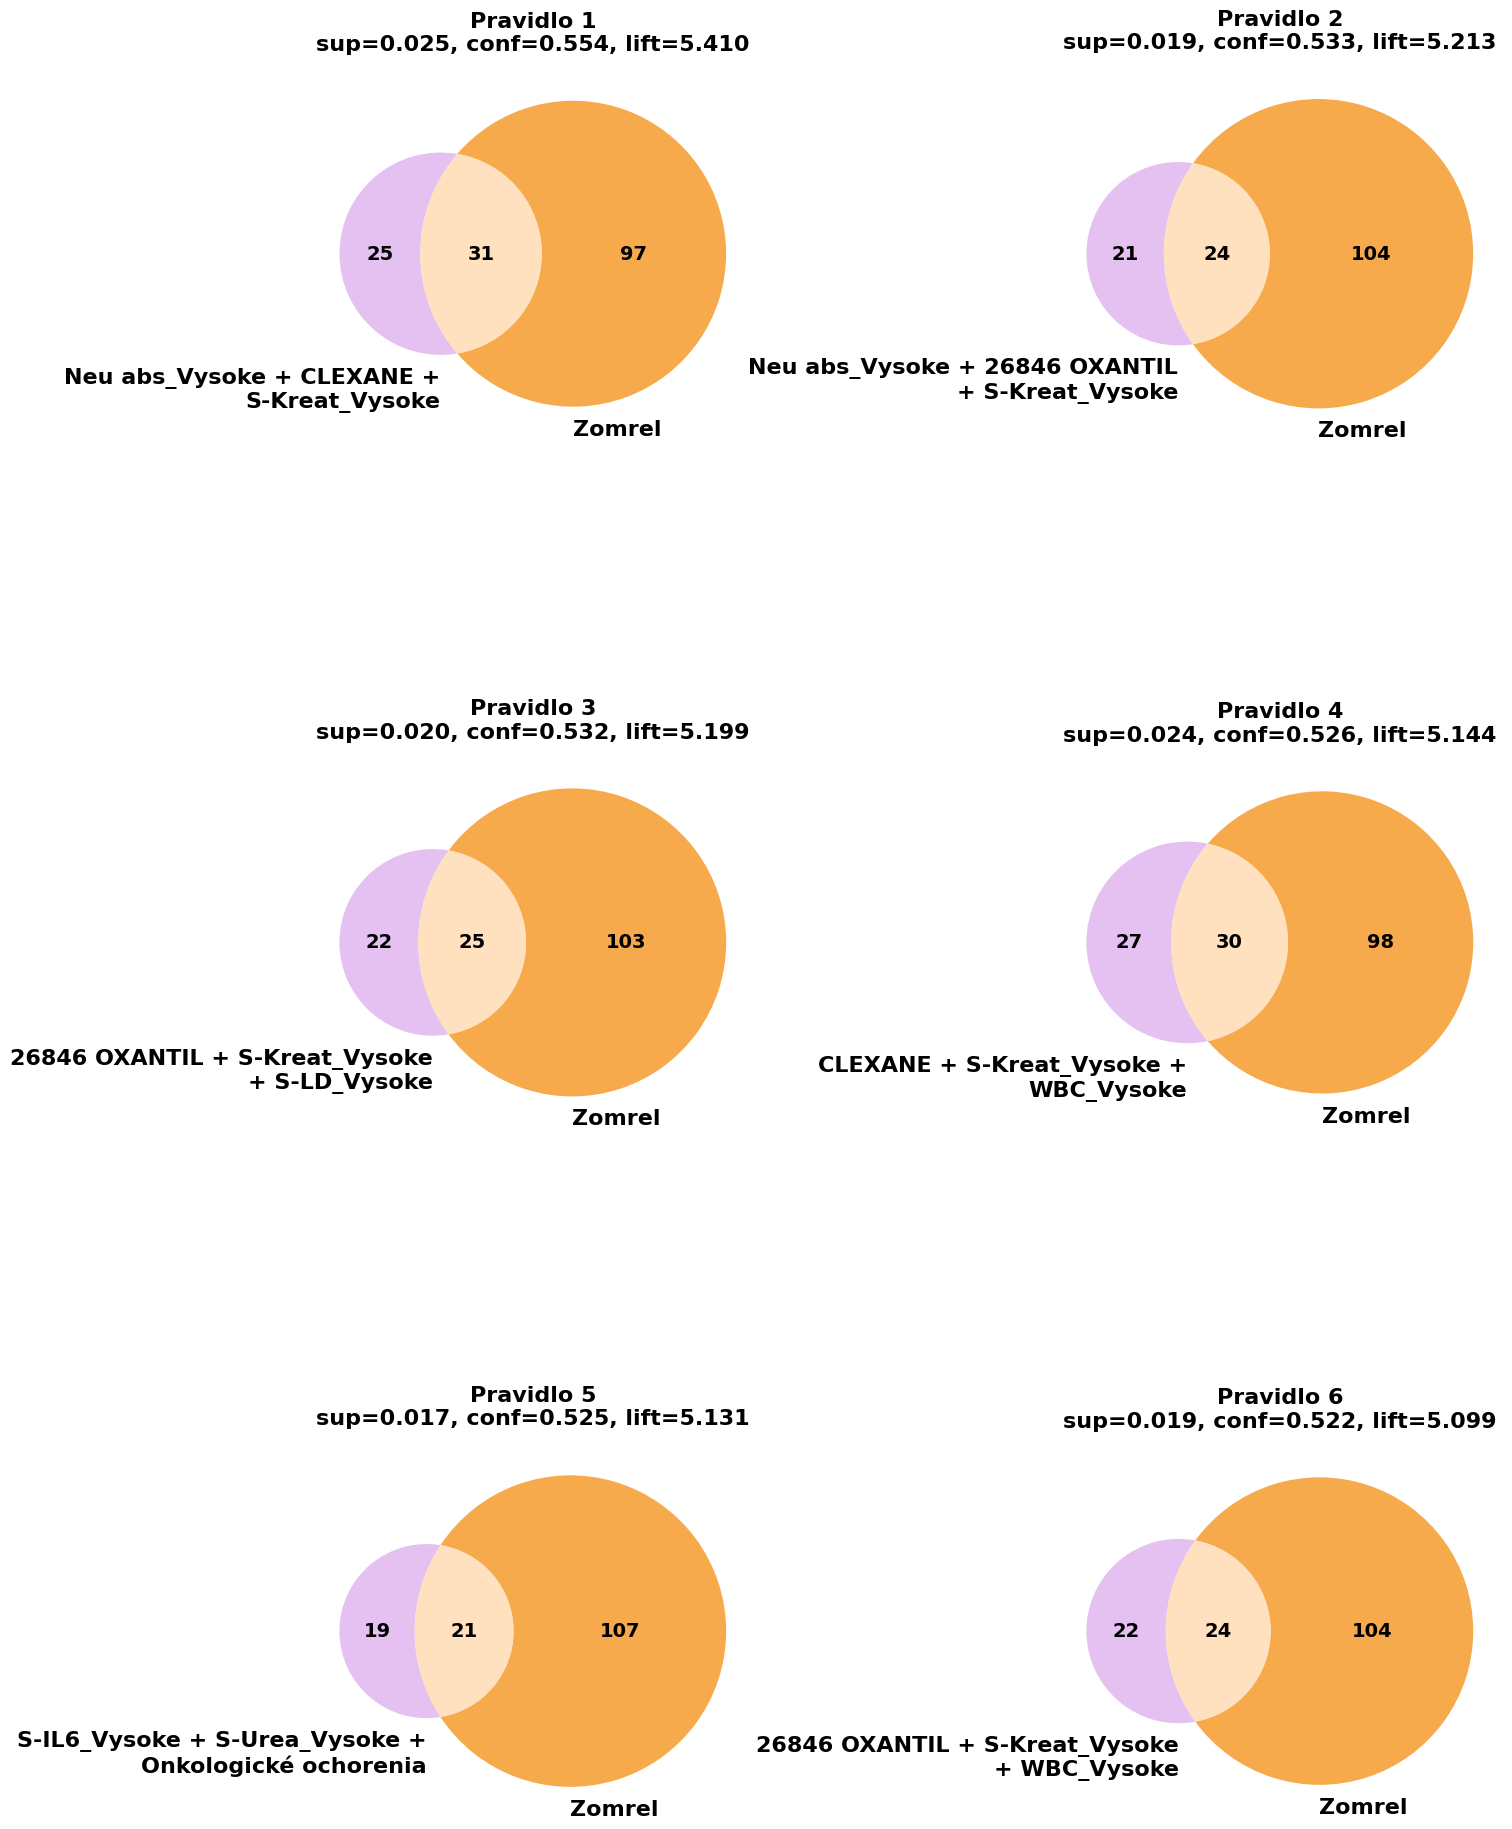

In [22]:
# Identifikácia najzaujímavejších pravidiel podľa komorbidít

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import math
import textwrap 

# Vennove diagramy pre pravidlá zo sieťového grafu

if rules_filtered.empty:
    print("Nie sú dostupné pravidlá pre Vennove diagramy.")
else:
    plot_rules = rules_filtered.head(min(6, len(rules_filtered))).copy()
    n_rules = len(plot_rules)
    cols = 2
    rows = math.ceil(n_rules / cols)

   
    fig, axes = plt.subplots(rows, cols, figsize=(15, 7 * rows))
    axes = np.array(axes).reshape(-1)

    for ax_idx, (_, rule) in enumerate(plot_rules.iterrows()):
        ax = axes[ax_idx]

        antecedents = list(rule["antecedents"])
        consequents = list(rule["consequents"])

        antecedent_mask = pd.Series(True, index=df_final.index)
        for item in antecedents:
            if item in df_final.columns:
                antecedent_mask &= df_final[item]

        consequent_item = list(consequents)[0]
        consequent_mask = df_final[consequent_item]

        antecedent_only = int((antecedent_mask & ~consequent_mask).sum())
        consequent_only = int((~antecedent_mask & consequent_mask).sum())
        intersection = int((antecedent_mask & consequent_mask).sum())

       
        label_ant = textwrap.fill(" + ".join(antecedents), width=30)
        label_con = textwrap.fill(consequent_item, width=30)

        v = venn2(
            subsets=(antecedent_only, consequent_only, intersection),
            set_labels=(label_ant, label_con),
            set_colors=('#d9a7eb', '#f38600'), 
            alpha=0.7,                         
            ax=ax
        )
        
        
        if v is not None:
            
            for text in v.subset_labels:
                if text is not None:
                    text.set_fontsize(14)
                    text.set_fontweight('bold')
            
           
            for text in v.set_labels:
                if text is not None:
                    text.set_fontsize(16)
                    text.set_fontweight('bold')

        
        ax.set_title(
            f"Pravidlo {ax_idx + 1}\n"
            f"sup={rule['support']:.3f}, conf={rule['confidence']:.3f}, lift={rule['lift']:.3f}",
            fontsize=16,          
            fontweight='bold',
            pad=15                
        )


    for j in range(ax_idx + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()